# Reproduce Figure 8
This notebook reproduces Figure 8, which contains 3 sub-sigures: memory, cost, and latency. These figures can be produced with either data provided by authors (`paper_results`) or data collected by the user (`results`).

In [5]:
from pathlib import Path
import pandas as pd
from scipy import stats
import numpy as np
from dataclasses import dataclass
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
use_provided_data = True # Set to True if you want to use the provided data, False to use data collected from the script
RESULTS_DIR = Path("paper_results") if use_provided_data else Path("results")
DEBLOATED_DIR = RESULTS_DIR / Path("debloated")
ORIGINAL_DIR = RESULTS_DIR  / Path("baseline")
OUTPUT_DIR = Path("figures")

In [7]:
PRICE_PER_MS_PER_MB_PER_100K_REQ = 0.00000162109
def get_estimated_cost(mem, time):
    # mem in MB, time in ms
    if mem < 128:
        mem = 128
    return mem * PRICE_PER_MS_PER_MB_PER_100K_REQ * time

@dataclass
class Result:  # in the form of (mean, std)
    prep: tuple[float, float]
    init: tuple[float, float]
    exec: tuple[float, float]
    inport: tuple[float, float]
    e2e: tuple[float, float]
    memory: tuple[float, float]
    cost: tuple[float, float]
    billed: tuple[float, float]


def filter_outlier(df, z_score=1):
    # Filter outliers rows based on e2e_latency
    z = np.abs(stats.zscore(df["e2e_latency"]))
    return df[(z < z_score)]

def get_phase_times_from_csv(file_name: str, dir: Path, z_score: int = 1):
    df = filter_outlier(pd.read_csv(dir / file_name), z_score)

    import_times = df["import_time"]
    init_times = df["billed_duration"] - df["duration"]
    prep_times = 1000 * df["e2e_latency"] - df["billed_duration"]

    billed_duration = df["billed_duration"]
    billed_mean = billed_duration.mean()
    billed_std = billed_duration.std()

    prep_mean = prep_times.mean()
    prep_std = prep_times.std()
    init_mean = init_times.mean()
    init_std = init_times.std()
    exec_mean = df["duration"].mean()
    exec_std = df["duration"].std()
    import_mean = import_times.mean()
    import_std = import_times.std()

    e2e_mean = df["e2e_latency"].mean()
    e2e_std = df["e2e_latency"].std()

    mem_mean = df["mem_used"].mean()
    mem_std = df["mem_used"].std()

    
    return Result(
        prep=(prep_mean, prep_std),
        init=(init_mean, init_std),
        exec=(exec_mean, exec_std),
        inport=(import_mean, import_std),
        e2e=(e2e_mean, e2e_std),
        memory=(mem_mean, mem_std),
        billed=(billed_mean, billed_std),
        cost=(get_estimated_cost(mem_mean, billed_mean), get_estimated_cost(mem_std, billed_std)),
    )

def generate_csv(apps: list[str], debloat: bool, z_score: int):
    import_time = []
    exec_time = []
    e2e_latency = []
    billed_duration = []
    memory = []
    cost = []

    #old_measurements = pd.read_csv(OUTPUT_DIR / Path("measurements_old.csv"))

    dir = ORIGINAL_DIR if not debloat else DEBLOATED_DIR

    for app in apps:
        file_name = f"{app}.csv" if not debloat else f"{app}-debloat.csv"
        # If file doesn't exits, use old mearuements
        # if not (dir / file_name).exists():
        #     print(f"{dir / file_name} not found, using old measurements")
        #     import_time.append(old_measurements[old_measurements["app"] == app]["import_time"].values[0])
        #     exec_time.append(old_measurements[old_measurements["app"] == app]["exec_time"].values[0])
        #     e2e_latency.append(old_measurements[old_measurements["app"] == app]["e2e_latency"].values[0])
        #     billed_duration.append(old_measurements[old_measurements["app"] == app]["billed_duration"].values[0])
        #     memory.append(old_measurements[old_measurements["app"] == app]["memory"].values[0])
        #     cost.append(old_measurements[old_measurements["app"] == app]["cost"].values[0])
        #     continue
        result = get_phase_times_from_csv(file_name, dir, z_score=z_score)
        # Convert from ms to seconds and keep 2 decimal
        import_mean = round(result.inport[0], 2)
        exec_mean = round(result.exec[0] / 1000, 2)
        e2e_mean = round(result.e2e[0], 2)
        billed = round(result.billed[0] / 1000, 2)
        mem_mean = round(result.memory[0], 2)
        import_time.append(import_mean)
        exec_time.append(exec_mean)
        e2e_latency.append(e2e_mean)
        billed_duration.append(billed)
        memory.append(mem_mean)
        cost.append(round(result.cost[0],2))
    
    df = pd.DataFrame({
        "app": apps,
        "import_time": import_time,
        "exec_time": exec_time,
        "e2e_latency": e2e_latency,
        "billed_duration": billed_duration,
        "memory": memory,
        "cost": cost
    })
    return df
# collect all apps with data
apps = [d.name[:-12] for d in DEBLOATED_DIR.iterdir()]
apps.sort()
print(f"Collected applications (total {len(apps)}):")

original_data = generate_csv(apps, False, 3)
debloated_data = generate_csv(apps, True, 3)
original_data.to_csv("tables/original_summary.csv", index=False)
debloated_data.to_csv("tables/debloated_summary.csv", index=False)

Collected applications (total 21):


# Plot

## Figure 8a: Latency

<Figure size 640x480 with 0 Axes>

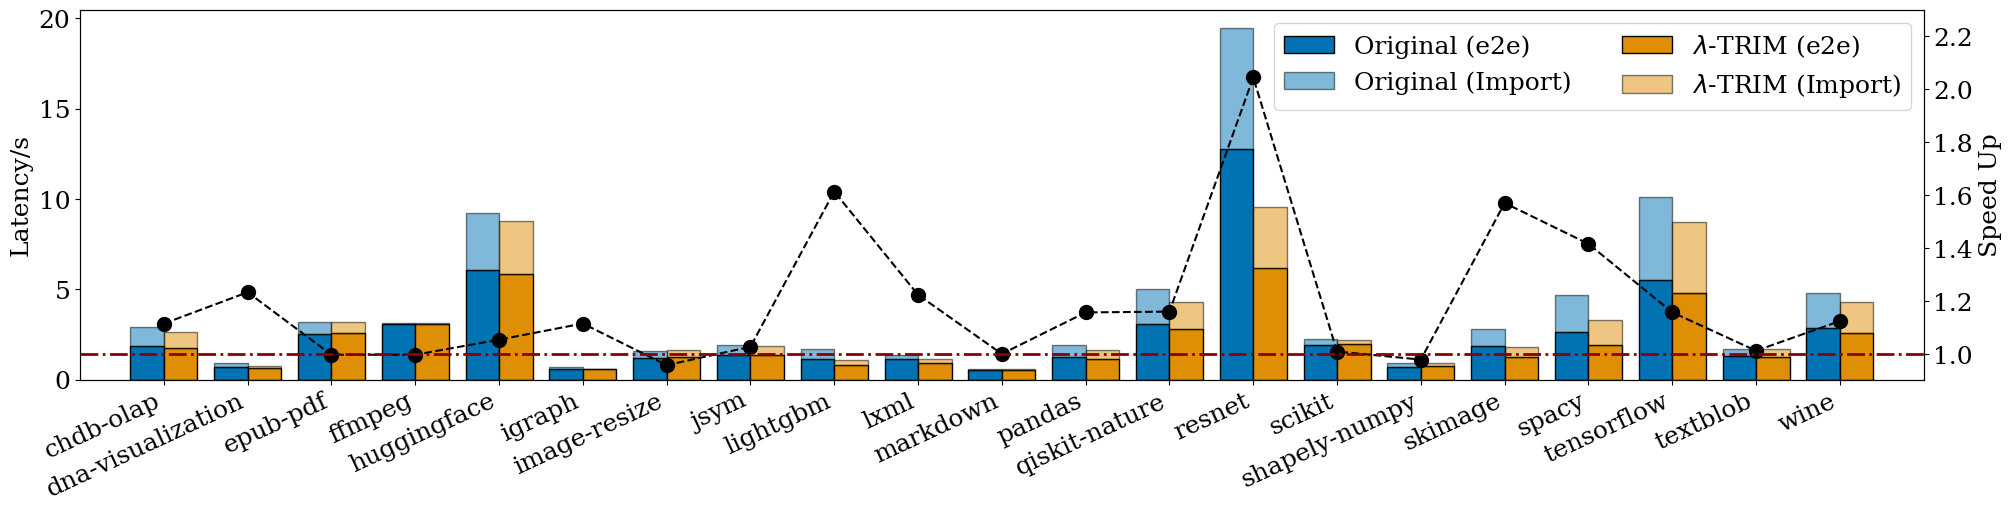

In [10]:
# latency = import time + e2e
plt.rc("font", size=18, family="serif")
plt.clf()
fig, ax_main = plt.subplots(figsize=(20, 5), layout="constrained")

x_axis = np.arange(len(apps))


def plot(
    data: pd.DataFrame, label: str, color: str
):
    inport, e2e = data["import_time"], data["e2e_latency"]
    dev = -0.2 if label == "Original" else 0.2

    with sns.color_palette("colorblind"):
        ax_main.bar(
            x_axis + dev, e2e, 0.4, label=f"{label} (e2e)", edgecolor="k",
            color=color
        )
        ax_main.bar(
            x_axis + dev,
            inport,
            0.4,
            bottom=e2e,
            label=f"{label} (Import)",
            color=color,
            alpha=0.5,
            edgecolor="k",
        )


plot(original_data, "Original", sns.color_palette("colorblind")[0])
plot(debloated_data, "$\\lambda$-TRIM", sns.color_palette("colorblind")[1])



ax_main.set_xticks(x_axis, apps, rotation=25, ha="right")
ax_main.set_ylabel("Latency/s")
ax_main.legend(ncol=2)

ax_impr = ax_main.twinx()
ax_impr.plot(
    x_axis,
    [
        ori / deb
        for (ori, deb) in zip(
            original_data["e2e_latency"] + original_data["import_time"],
            debloated_data["e2e_latency"] + debloated_data["import_time"],
        )
    ],
    color="black",
    marker="o",
    markersize=10,
    linestyle="--"
)
_extended_x_axis = np.arange(-1, len(apps) + 1)
ax_impr.plot(
    _extended_x_axis,
    np.ones_like(_extended_x_axis),
    color="darkred",
    linestyle="-.",
    linewidth=2,
)
ax_impr.set_xlim(-1, len(apps))
ax_impr.set_ylabel("Speed Up")
ymin, ymax = ax_impr.set_ylim()
ax_impr.set_ylim(ymin, ymax + 0.2)

plt.savefig(OUTPUT_DIR / "fig8a.pdf")
plt.show()

## Figure 8b: Memory

In [11]:

def split(ls: list[tuple[float, float]]):
    return [i[0] for i in ls], [i[1] for i in ls]


def plot_data(
    original: pd.DataFrame,
    debloated: pd.DataFrame,
    apps: list[str],
    aspect: str,
    label: str,
):
    improvment = [(ori - deb) * 100 / ori for (ori, deb) in zip(original[aspect], debloated[aspect])]

    x_axis = np.arange(len(apps))


    with sns.color_palette("colorblind"):
        plt.clf()
        fig, ax_main = plt.subplots(figsize=(20, 5), layout="constrained")

        ax_main.bar(x_axis - 0.2, original[aspect], 0.4, label="Original", edgecolor="k")
        ax_main.bar(x_axis + 0.2, debloated[aspect], 0.4, label="$\\lambda$-TRIM", edgecolor="k")
        ax_main.set_xticks(x_axis, apps, rotation=25, ha="right")
        ax_main.set_ylabel(label, fontsize=20)
        ax_main.set_yscale("log")

        ax_impr = ax_main.twinx()
        ax_impr.plot(x_axis, improvment, marker="o", color="black", markersize=10, linestyle="--")
        _extended_x_axis = np.arange(-1, len(apps) + 1)
        ax_impr.plot(
            _extended_x_axis,
            np.zeros_like(_extended_x_axis),
            color="darkred",
            linestyle="-.",
            linewidth=2,
        )
        ax_impr.set_xlim(-1, len(apps))
        ax_impr.set_ylabel("Improvment/%", fontsize=20)
        ymin, ymax = ax_impr.set_ylim()
        ax_impr.set_ylim(ymin, ymax + 6)

        ax_main.legend()
        plt.savefig(OUTPUT_DIR / f"figure8-{aspect}.pdf")
        plt.show()

<Figure size 640x480 with 0 Axes>

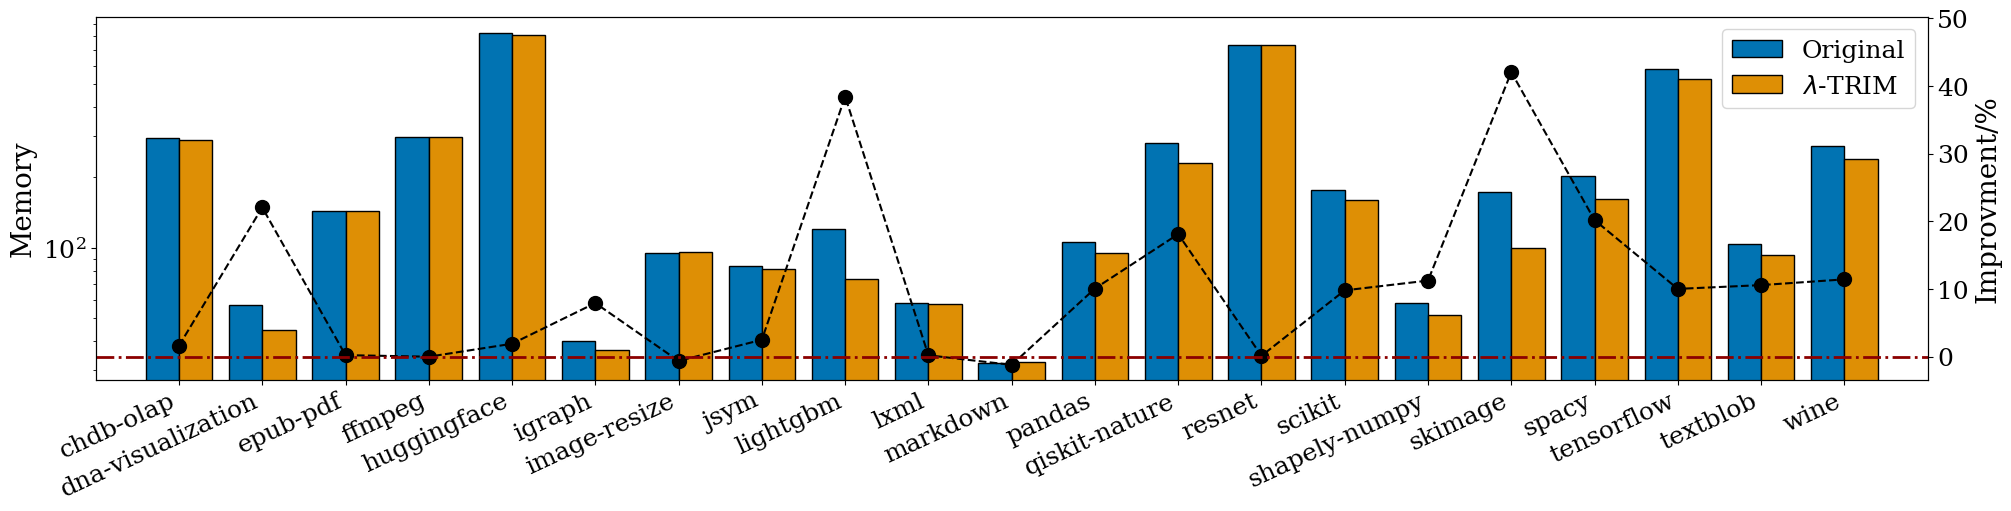

In [12]:
plot_data(original_data, debloated_data, apps, "memory", "Memory")

## Figure 8c: Cost

<Figure size 640x480 with 0 Axes>

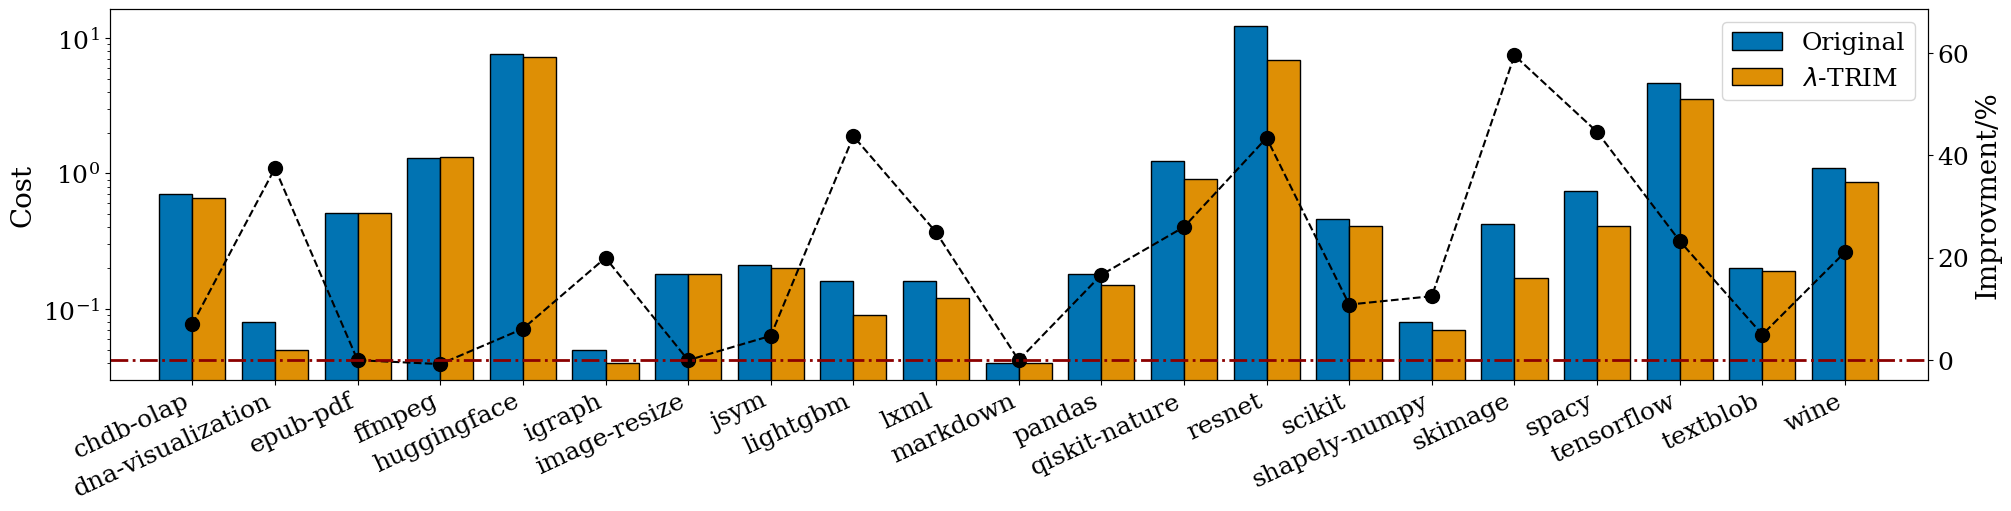

In [13]:
plot_data(original_data, debloated_data, apps, "cost", "Cost")